In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [3]:
football = pd.read_excel("premierLeague.xlsx")

In [6]:
football

,Match_Name,Match_Date,Team,Team_Logo,Manager,Captain,Score,Penalties,Fouls,Corners,...,Possession,PassingAccuracy,SucPass,NumofPass,ShotsAccuracy,SucShots,NumofShots,SavesAccuracy,SucSaves,NumofSaves
0,Liverpool vs. Norwich City,2019-08-09,Liverpool,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Jürgen Klopp,Jordan Henderson,4,0,10,11,...,0.57,0,409,521,0.47,7,15,0.83,5,6
1,Liverpool vs. Norwich City,2019-08-09,Norwich City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Daniel Farke,Grant Hanley,1,0,12,2,...,0.43,0,304,395,0.46,6,13,0.42,3,7
2,West Ham United vs. Manchester City,2019-08-10,West Ham United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Manuel Pellegrini,Aaron Cresswell,0,0,11,1,...,0.43,0,347,428,0.60,3,5,0.50,4,8
3,West Ham United vs. Manchester City,2019-08-10,Manchester City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Pep Guardiola,David Silva,5,0,15,1,...,0.57,0,495,564,0.62,8,13,1.00,3,3
4,Burnley vs. Southampton,2019-08-10,Burnley,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Sean Dyche,Ben Mee,3,0,6,2,...,0.46,0,214,346,0.44,4,9,1.00,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,Manchester City vs. Norwich City,2020-07-26,Norwich City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Daniel Farke,Christoph Zimmermann,0,0,6,0,...,0.27,0,190,277,0.80,4,5,0.44,4,9
756,Leicester City vs. Manchester United,2020-07-26,Leicester City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Brendan Rodgers,Wes Morgan,0,0,12,3,...,0.47,0,383,474,0.21,3,14,0.50,1,2
757,Leicester City vs. Manchester United,2020-07-26,Manchester United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Ole Gunnar Solskjær,Harry Maguire,2,0,12,3,...,0.53,0,438,532,0.33,2,6,1.00,3,3
758,Newcastle United vs. Liverpool,2020-07-26,Newcastle United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Steve Bruce,Jonjo Shelvey,1,0,14,2,...,0.25,0,192,285,0.67,2,3,0.50,3,6


In [8]:
#To delete and remove the specific columns if they contain only zeros


columns_to_check = ['Penalties', 'PassingAccuracy' ]
football = football.drop(columns=[col for col in columns_to_check if football[col].eq(0).all()])

In [10]:
football #can be seen that the columns penalties, and passing accuracy have been deleted

,Match_Name,Match_Date,Team,Team_Logo,Manager,Captain,Score,Fouls,Corners,Crosses,...,YellowRed,Possession,SucPass,NumofPass,ShotsAccuracy,SucShots,NumofShots,SavesAccuracy,SucSaves,NumofSaves
0,Liverpool vs. Norwich City,2019-08-09,Liverpool,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Jürgen Klopp,Jordan Henderson,4,10,11,15,...,0,0.57,409,521,0.47,7,15,0.83,5,6
1,Liverpool vs. Norwich City,2019-08-09,Norwich City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Daniel Farke,Grant Hanley,1,12,2,5,...,0,0.43,304,395,0.46,6,13,0.42,3,7
2,West Ham United vs. Manchester City,2019-08-10,West Ham United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Manuel Pellegrini,Aaron Cresswell,0,11,1,10,...,0,0.43,347,428,0.60,3,5,0.50,4,8
3,West Ham United vs. Manchester City,2019-08-10,Manchester City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Pep Guardiola,David Silva,5,15,1,8,...,0,0.57,495,564,0.62,8,13,1.00,3,3
4,Burnley vs. Southampton,2019-08-10,Burnley,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Sean Dyche,Ben Mee,3,6,2,7,...,0,0.46,214,346,0.44,4,9,1.00,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,Manchester City vs. Norwich City,2020-07-26,Norwich City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Daniel Farke,Christoph Zimmermann,0,6,0,3,...,0,0.27,190,277,0.80,4,5,0.44,4,9
756,Leicester City vs. Manchester United,2020-07-26,Leicester City,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Brendan Rodgers,Wes Morgan,0,12,3,13,...,0,0.47,383,474,0.21,3,14,0.50,1,2
757,Leicester City vs. Manchester United,2020-07-26,Manchester United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Ole Gunnar Solskjær,Harry Maguire,2,12,3,6,...,0,0.53,438,532,0.33,2,6,1.00,3,3
758,Newcastle United vs. Liverpool,2020-07-26,Newcastle United,https://d2p3bygnnzw9w3.cloudfront.net/req/2020...,Steve Bruce,Jonjo Shelvey,1,14,2,3,...,0,0.25,192,285,0.67,2,3,0.50,3,6


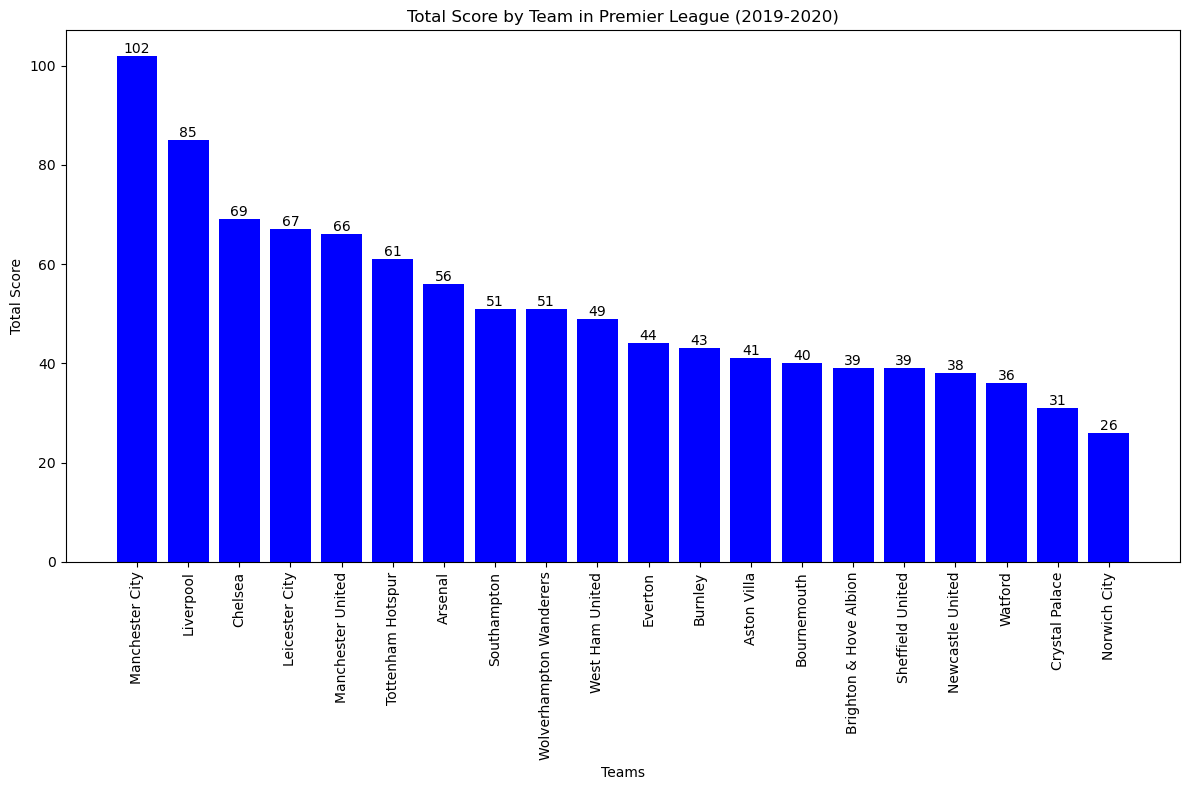

In [12]:
# To calculate the total goals for each team
team_scores = football.groupby('Team')['Score'].sum().reset_index()

#To sort the data by score in descending order - from highest to lowest for clear display
team_scores = team_scores.sort_values(by='Score', ascending=False)


# we use bar chart to compare the total score of each team
plt.figure(figsize=(12,8))
bars = plt.bar(team_scores['Team'], team_scores['Score'], color='blue')
plt.xticks(rotation=90)
plt.title('Total Score by Team in Premier League (2019-2020)')
plt.xlabel('Teams')
plt.ylabel('Total Score')

# for clearer and better visualisation, we add the total goals of each team on top of the bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()


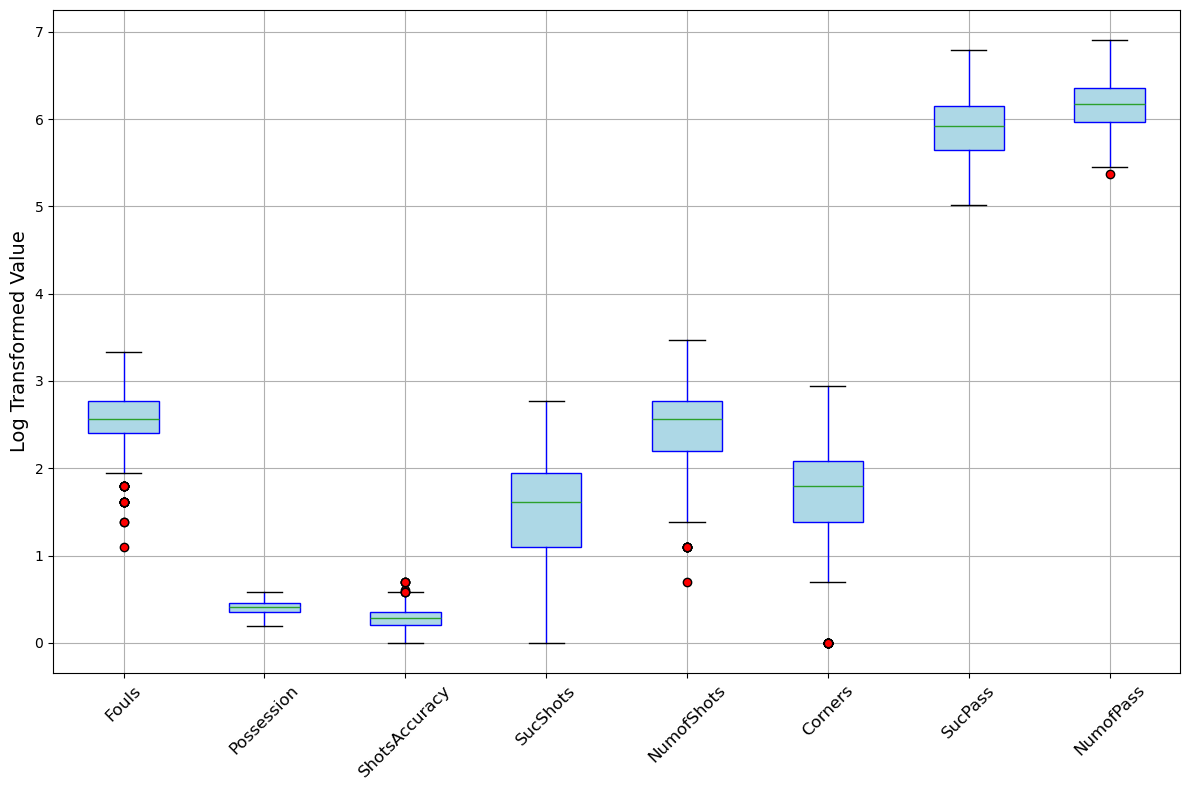

In [14]:
#We select the columns which are numerical and we want to analyse 
numerical_columns = ['Fouls', 'Possession', 'ShotsAccuracy', 'SucShots', 'NumofShots', 'Corners', 'SucPass', 'NumofPass']

# We apply the log transformation to reduce the impact of extreme values and for better visualisation
football_log = football[numerical_columns].apply(lambda x: np.log1p(x))

# The code to create the boxplot
plt.figure(figsize=(12, 8))
football_log.boxplot(rot=45, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), whiskerprops=dict(color='blue'), flierprops=dict(markerfacecolor='red', marker='o'))
plt.ylabel('Log Transformed Value', fontsize=14)
plt.xticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Available teams in the dataset:
Liverpool
Norwich City
West Ham United
Manchester City
Burnley
Southampton
Watford
Brighton & Hove Albion
Bournemouth
Sheffield United
Crystal Palace
Everton
Tottenham Hotspur
Aston Villa
Newcastle United
Arsenal
Leicester City
Wolverhampton Wanderers
Manchester United
Chelsea



Enter the first team from the list above:  Manchester City
Enter the second team from the list above:  liverpool


One or both teams are not in the dataset. Please check the available teams.

Available match dates between Manchester City and liverpool:
2019-11-10 00:00:00
2020-07-02 00:00:00



Enter the date of the match you'd like to see (YYYY-MM-DD):  2020-07-02


/var/folders/sd/y1zbkf7x3474t_5ybk1dyybm0000gn/T/ipykernel_77408/619304046.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_on_date['Possession'] = (match_on_date['Possession'] / match_on_date['Possession'].sum()) * 100


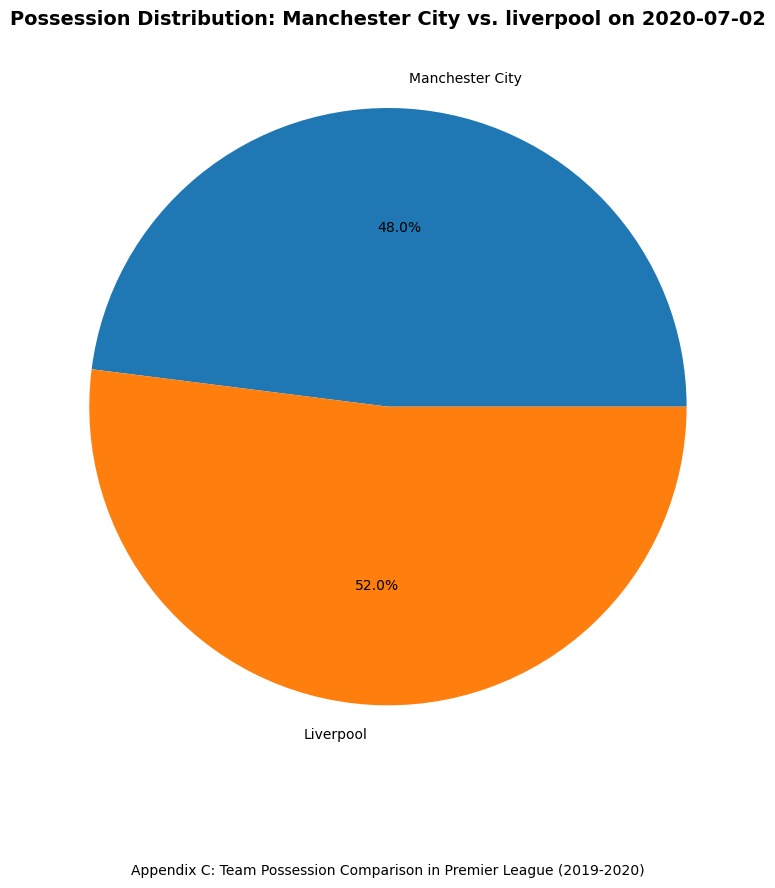

In [16]:
#Appendix A: Code for user query 
#Appendix C: the graph used to show the stats


# to show  all available teams in the dataset
available_teams = football['Team'].unique()
print("Available teams in the dataset:")
for team in available_teams:
    print(team)

# User input for two teams
team1 = input("\nEnter the first team from the list above: ")
team2 = input("Enter the second team from the list above: ")

# to validate input
if team1 not in available_teams or team2 not in available_teams:
    print(f"One or both teams are not in the dataset. Please check the available teams.")
    exit()

# Caps or small letters are ok 
team1_lower = team1.lower()
team2_lower = team2.lower()

# Filter the DataFrame for matches involving both teams
football_match = football[
    (football['Match_Name'].str.contains(team1, case=False)) & 
    (football['Match_Name'].str.contains(team2, case=False))
]

# Check if there are matches between the two teams
if not football_match.empty:
    available_dates = football_match['Match_Date'].unique()
    

    print(f"\nAvailable match dates between {team1} and {team2}:")
    for date in available_dates:
        print(date)
    
    # User selects a date
    selected_date = input("\nEnter the date of the match you'd like to see (YYYY-MM-DD): ").strip()
    
    # Filter the DataFrame for the selected match date
    match_on_date = football_match[football_match['Match_Date'] == selected_date]
    
    # Check if data is available for the selected date and for both teams
    if not match_on_date.empty and match_on_date['Team'].nunique() == 2:
        
        match_on_date['Possession'] = (match_on_date['Possession'] / match_on_date['Possession'].sum()) * 100
        
        # Plot the pie chart for Possession distribution
        plt.figure(figsize=(8, 8))
        plt.pie(
            match_on_date['Possession'],
            labels=match_on_date['Team'],
            autopct='%1.1f%%'
        )
        # Dynamic title based on user input
        plt.title(f'Possession Distribution: {team1} vs. {team2} on {selected_date}', fontsize=14, weight='bold')
        
        # caption below the chart
        caption_text = "Appendix C: Team Possession Comparison in Premier League (2019-2020)"
        plt.figtext(0.5, -0.1, caption_text, wrap=True, horizontalalignment='center', fontsize=10)

        # Adjust layout and show the chart
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data for both teams is not available for {team1} and {team2} on {selected_date}.")
else:
    print(f"No matches found between {team1} and {team2}.")  


Available teams in the dataset:
Liverpool
Norwich City
West Ham United
Manchester City
Burnley
Southampton
Watford
Brighton & Hove Albion
Bournemouth
Sheffield United
Crystal Palace
Everton
Tottenham Hotspur
Aston Villa
Newcastle United
Arsenal
Leicester City
Wolverhampton Wanderers
Manchester United
Chelsea



Enter the first team from the list above:  manchester city
Enter the second team from the list above:  liverpool


One or both teams are not in the dataset. Please check the available teams.

Available match dates between manchester city and liverpool:
2019-11-10 00:00:00
2020-07-02 00:00:00



Enter the date of the match you'd like to see (YYYY-MM-DD):  2020-07-02


<Figure size 1000x600 with 0 Axes>

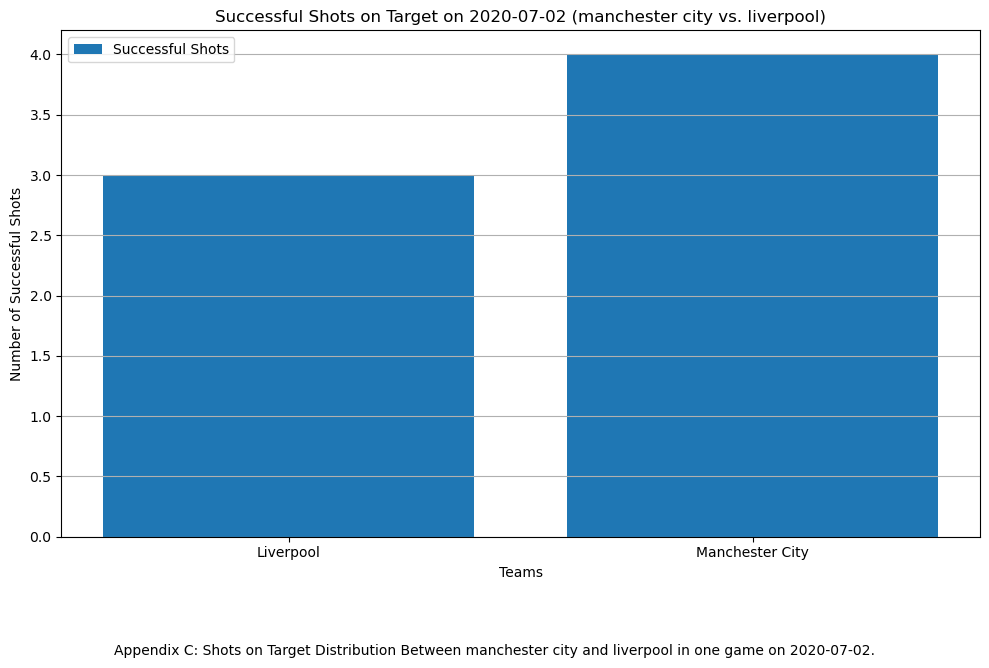

In [16]:
#Appendix A: Code for user query 
#Appendix C: the graph used to show the stats



# show all available teams in the dataset
available_teams = football['Team'].unique()
print("Available teams in the dataset:")
for team in available_teams:
    print(team)

# User input for two teams
team1 = input("\nEnter the first team from the list above: ")
team2 = input("Enter the second team from the list above: ")

# to validate input
if team1 not in available_teams or team2 not in available_teams:
    print(f"One or both teams are not in the dataset. Please check the available teams.")
    exit()

# Caps or small letters are ok 
team1_lower = team1.lower()
team2_lower = team2.lower()

# Filter the DataFrame for matches involving both teams
football_match = football[
    (football['Match_Name'].str.contains(team1, case=False)) & 
    (football['Match_Name'].str.contains(team2, case=False))
]

# Check if there are matches between the two teams
if not football_match.empty:
    available_dates = football_match['Match_Date'].unique()
    
    
    print(f"\nAvailable match dates between {team1} and {team2}:")
    for date in available_dates:
        print(date)
    
    # User selects a date
    selected_date = input("\nEnter the date of the match you'd like to see (YYYY-MM-DD): ").strip()
    
    # Filter the DataFrame for the selected match date
    match_on_date = football_match[football_match['Match_Date'] == selected_date]
    
    # we check if data is available for the selected date and for both teams
    if not match_on_date.empty:
        # Creating a stacked bar chart for successful shots
        plt.figure(figsize=(10, 6))

        # Creating a stacked bar chart for successful shots
plt.figure(figsize=(10, 6))

# Get successful shots for each team
team_data = match_on_date.groupby('Team')['SucShots'].sum().reset_index()

# Plotting the stacked bar chart
plt.bar(team_data['Team'], team_data['SucShots'], label='Successful Shots')

# Add title and labels
plt.title(f'Successful Shots on Target on {selected_date} ({team1} vs. {team2})')
plt.xlabel('Teams')
plt.ylabel('Number of Successful Shots')
plt.legend()
plt.grid(axis='y')

# Adding a caption below the graph
caption_text = (
    f"Appendix C: Shots on Target Distribution Between {team1} and {team2} "
    f"in one game on {selected_date}."
)
plt.figtext(0.5, -0.1, caption_text, wrap=True, horizontalalignment='center', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


/var/folders/sd/y1zbkf7x3474t_5ybk1dyybm0000gn/T/ipykernel_77468/1917976457.py:4: FutureWarning: The provided callable <function mean at 0x108258720> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  metrics_summary = football[numerical_columns].agg([np.mean, np.median, lambda x: x.mode()[0]])
/var/folders/sd/y1zbkf7x3474t_5ybk1dyybm0000gn/T/ipykernel_77468/1917976457.py:4: FutureWarning: The provided callable <function median at 0x108373420> is currently using Series.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  metrics_summary = football[numerical_columns].agg([np.mean, np.median, lambda x: x.mode()[0]])
/var/folders/sd/y1zbkf7x3474t_5ybk1dyybm0000gn/T/ipykernel_77468/1917976457.py:4: FutureWarning: The provided callable <function mean at 0x108258720> is currently using S

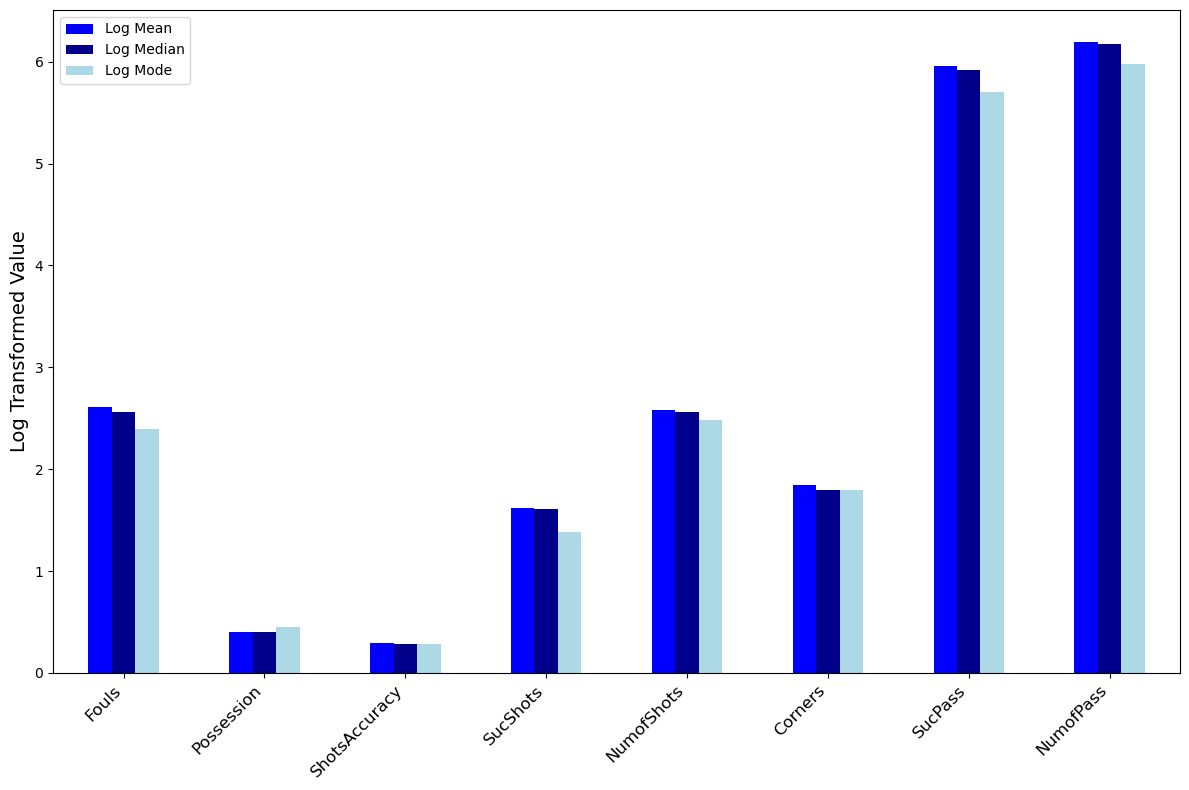

In [16]:
#using numerical_columns variable from the above code to apply for central tendency 
# to calculate the mean, median and mode for the selected columns

metrics_summary = football[numerical_columns].agg([np.mean, np.median, lambda x: x.mode()[0]])

# to apply log transformation function for enhancened visualisation
metrics_summary_log = metrics_summary.apply(np.log1p)  # log1p handles zero values properly

# we put results in different columns for better plotting
metrics_summary_log = metrics_summary_log.T
metrics_summary_log.columns = ['Log Mean', 'Log Median', 'Log Mode']

# code for plotting the central tendency
metrics_summary_log.plot(kind='bar', figsize=(12, 8), color=['blue', 'darkblue', 'lightblue'])
plt.ylabel('Log Transformed Value', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()


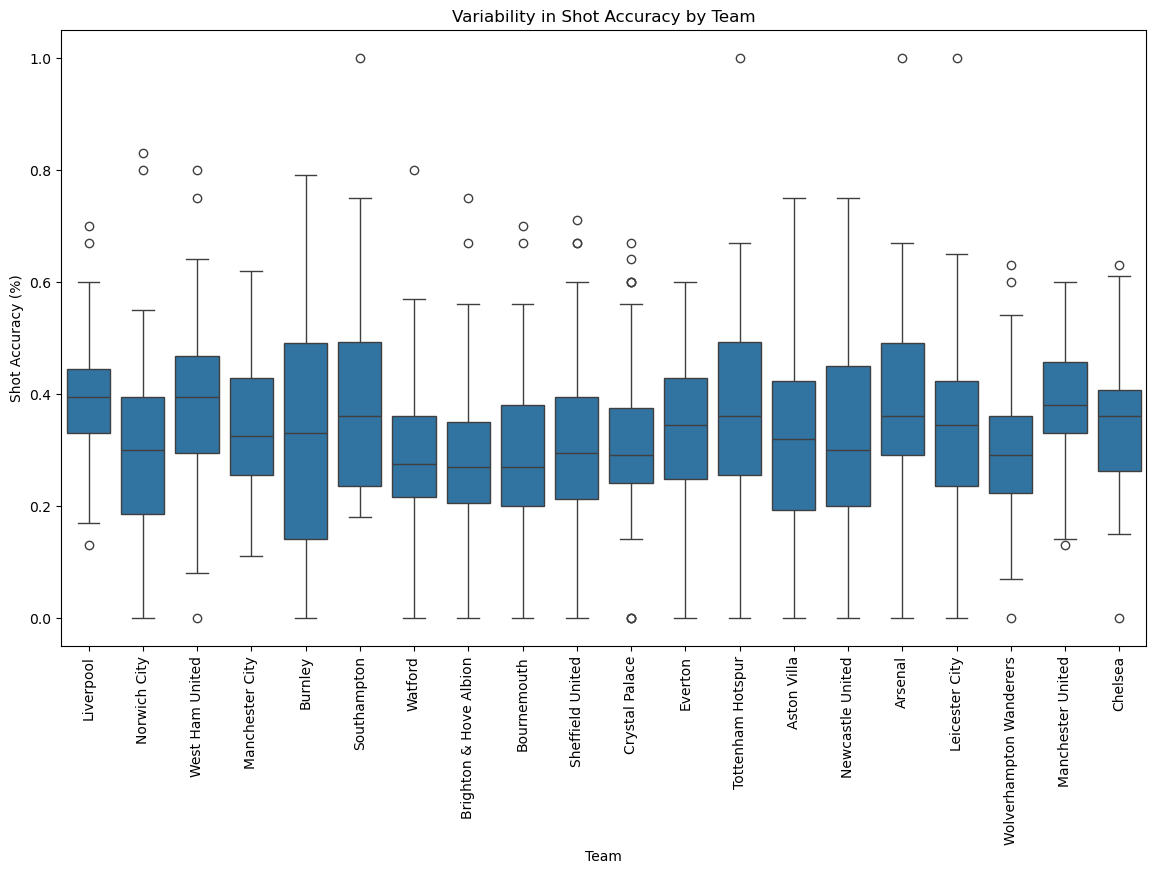

In [21]:
#Figure 4:

# Boxplot to compare shot accuracy between teams
plt.figure(figsize=(14, 8))
sns.boxplot(x='Team', y='ShotsAccuracy', data=football)
plt.xticks(rotation=90)
plt.title('Variability in Shot Accuracy by Team')
plt.xlabel('Team')
plt.ylabel('Shot Accuracy (%)')
plt.show()

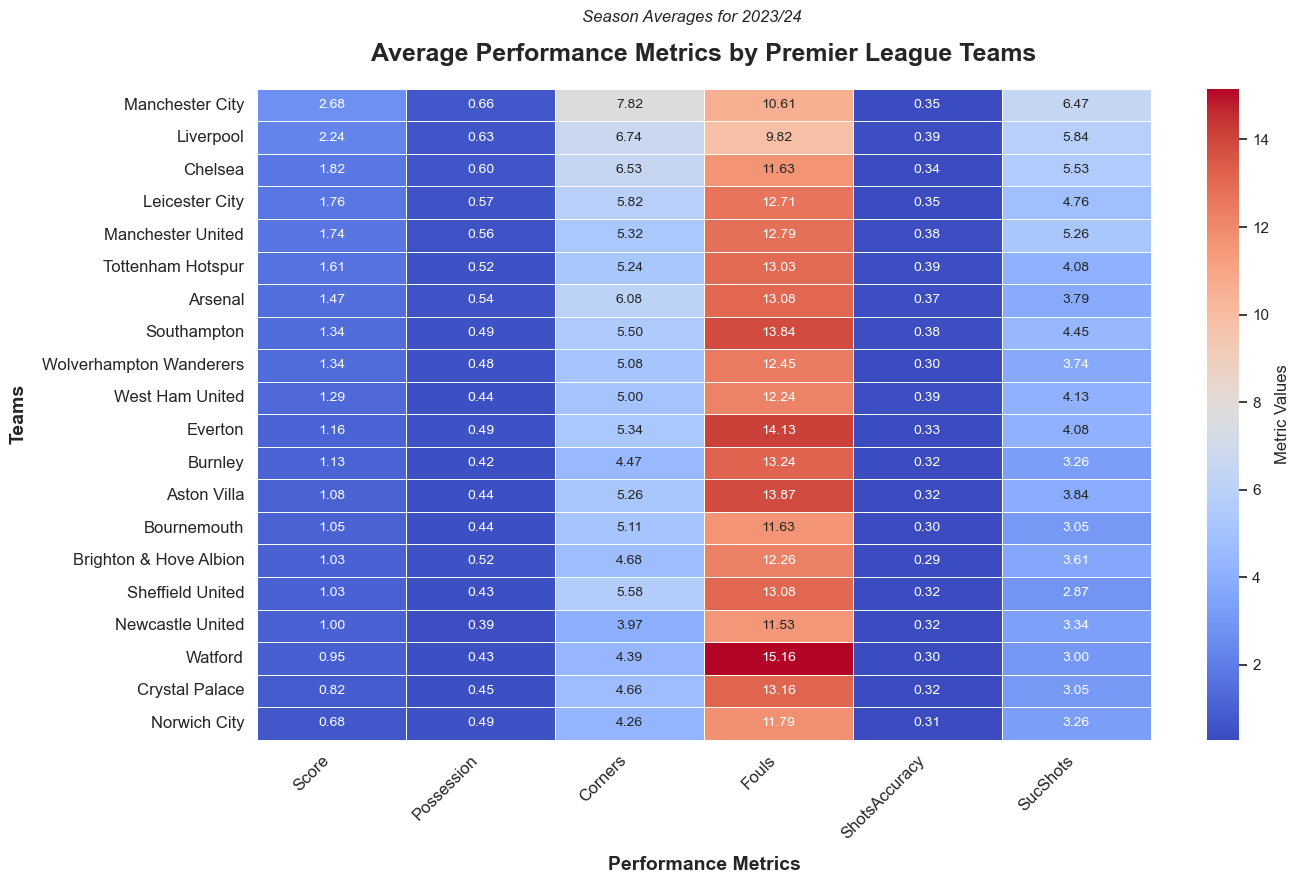

In [25]:
#Figure 5:


# Selecting relevant columns
selected_columns = ['Team', 'Score', 'Possession', 'Corners', 'Fouls', 'ShotsAccuracy', 'SucShots']
subset = football[selected_columns]

# Grouping by Team and calculate mean for each metric
team_metrics = subset.groupby('Team').mean().reset_index()

# Setting a professional theme
sns.set_theme(style="whitegrid")

# Sorting data based on a meaningful metric
team_metrics = team_metrics.sort_values(by="Score", ascending=False)

# Create the heatmap
plt.figure(figsize=(14, 9))  # Larger figure for better clarity
ax = sns.heatmap(
    team_metrics.set_index("Team"),  # Set "Team" as the index
    cmap="coolwarm",                # Use a professional color palette
    annot=True,                     # Add numerical annotations
    fmt=".2f",                      # Format for numerical annotations
    annot_kws={"size": 10},         # Increase annotation font size
    linewidths=0.5,                 # Add gridlines
    cbar_kws={'label': 'Metric Values'}  # Add a label to the color bar
)

# Title and subtitle
plt.title("Average Performance Metrics by Premier League Teams", fontsize=18, weight='bold', pad=20)  # Add padding to the main title
plt.suptitle("Season Averages for 2023/24", fontsize=12, style='italic', y=0.98)  # Adjust placement of subtitle

#  adding labels
plt.xlabel("Performance Metrics", fontsize=14, weight='bold', labelpad=10)  # Add padding to x-axis label
plt.ylabel("Teams", fontsize=14, weight='bold', labelpad=10)  # Add padding to y-axis label

# rotating labels 
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# adjusting layout
plt.tight_layout()


plt.show()


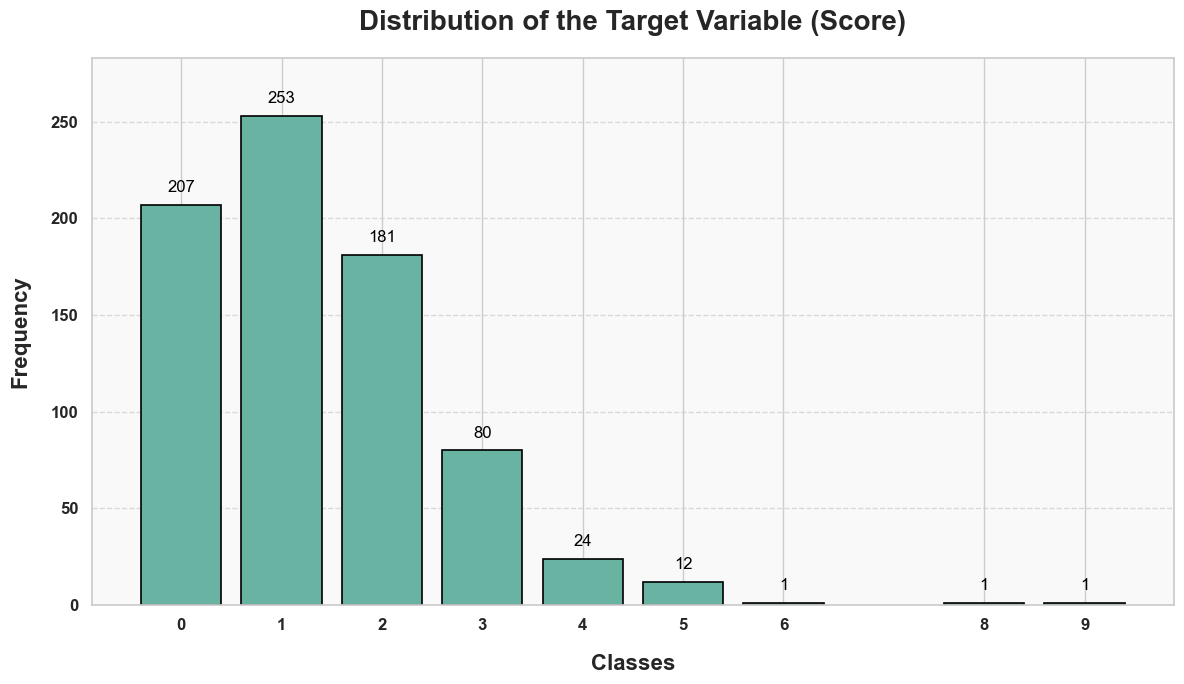

In [27]:
#Figure 6:

# calculating score counts and sorting in descending order
class_counts = football['Score'].value_counts().sort_index()  # Sort index for proper numeric order

# plotting the vertical bar chart
plt.figure(figsize=(12, 7))  # Increased figure size for clarity
bars = plt.bar(class_counts.index, class_counts.values, color='#69b3a2', edgecolor='black', linewidth=1.2)

# Adding titles
plt.title("Distribution of the Target Variable (Score)", fontsize=20, weight='bold', pad=20, family='Arial')
plt.xlabel("Classes", fontsize=16, weight='bold', labelpad=15, family='Arial')
plt.ylabel("Frequency", fontsize=16, weight='bold', labelpad=15, family='Arial')

# Annotateing bars with their frequency values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{int(height)}', 
             ha='center', va='bottom', fontsize=12, family='Arial', color='black')

# Adjusting y-axis limits to provide extra space above the tallest bar
plt.ylim(0, class_counts.max() + 30) 

# Customising tick labels
plt.xticks(ticks=class_counts.index, labels=class_counts.index, fontsize=12, weight='bold', family='Arial')  # Ensure proper labels
plt.yticks(fontsize=12, weight='bold', family='Arial')

# Adding gridlines for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add lighting gray background for a cleaner look
plt.gca().set_facecolor('#f9f9f9')


plt.tight_layout()

plt.show()


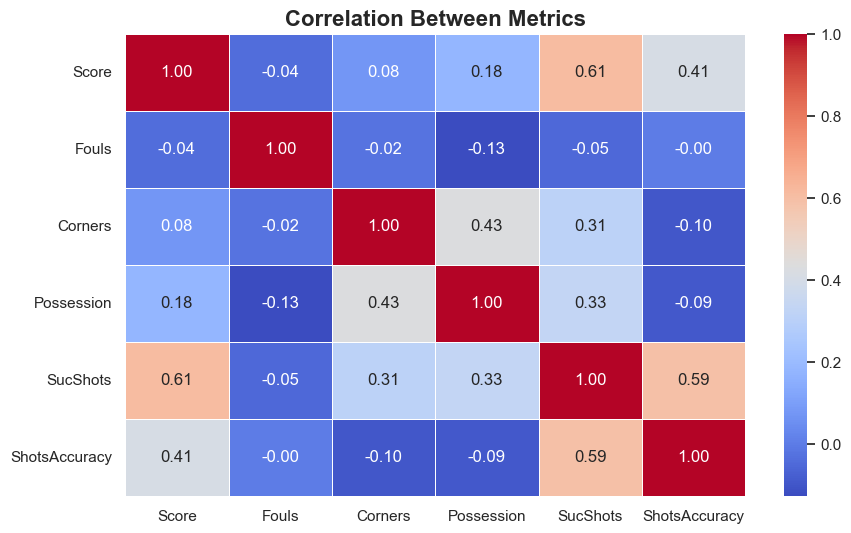

In [29]:
#Figure 7:

# Calculating correlation matrix
correlation_matrix = football[['Score', 'Fouls', 'Corners', 'Possession', 'SucShots', 'ShotsAccuracy']].corr()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Metrics", fontsize=16, weight='bold')
plt.show()


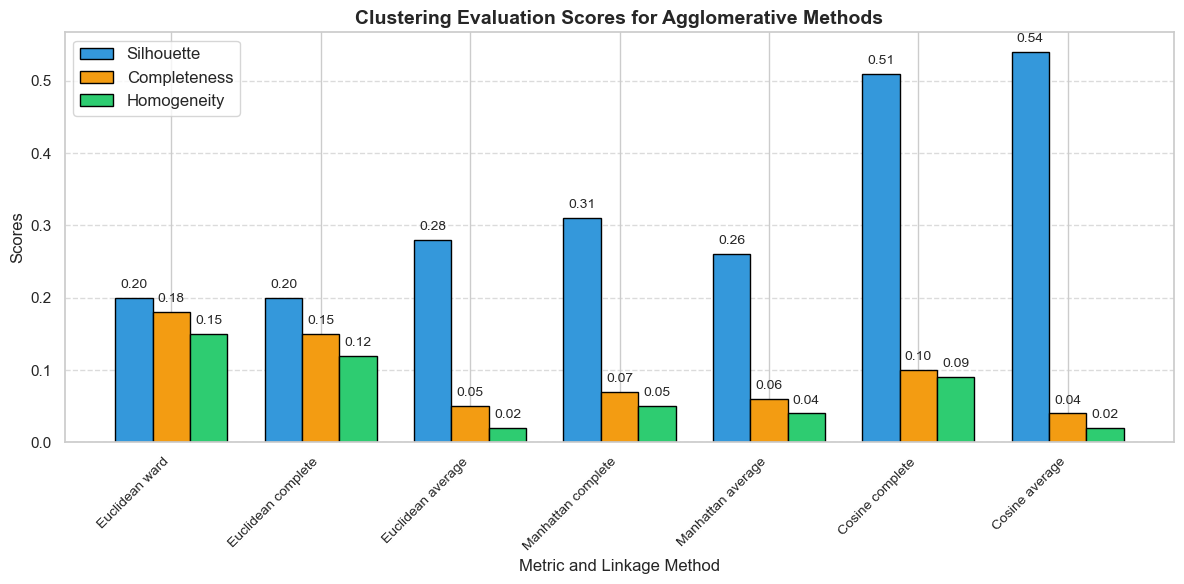

In [35]:
#Figure 8:


# Data from the clustering evaluation
labels_for_x_axis = [
    "Euclidean ward", "Euclidean complete", "Euclidean average",
    "Manhattan complete", "Manhattan average", "Cosine complete", "Cosine average"
]
silhouette_scores = [0.20, 0.20, 0.28, 0.31, 0.26, 0.51, 0.54]
completeness_scores = [0.18, 0.15, 0.05, 0.07, 0.06, 0.10, 0.04]
homogeneity_scores = [0.15, 0.12, 0.02, 0.05, 0.04, 0.09, 0.02]

# Positioning for the bars
x = np.arange(len(labels_for_x_axis))  # The number of clustering methods
width = 0.25  # Width of the bars

# Creating a figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting bars for each metric
rects1 = ax.bar(x - width, silhouette_scores, width, label='Silhouette', color='#3498db', edgecolor='black')
rects2 = ax.bar(x, completeness_scores, width, label='Completeness', color='#f39c12', edgecolor='black')
rects3 = ax.bar(x + width, homogeneity_scores, width, label='Homogeneity', color='#2ecc71', edgecolor='black')

# Setting labels and titles and grid
ax.set_xlabel('Metric and Linkage Method', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Clustering Evaluation Scores for Agglomerative Methods', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_for_x_axis, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the values on top of each bar for clarity
def add_values(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',  # Limit to 2 decimal places
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Offset text slightly above the bar
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_values(rects1)
add_values(rects2)
add_values(rects3)

# Adjust layout and show/save the figure
fig.tight_layout()
plt.show()


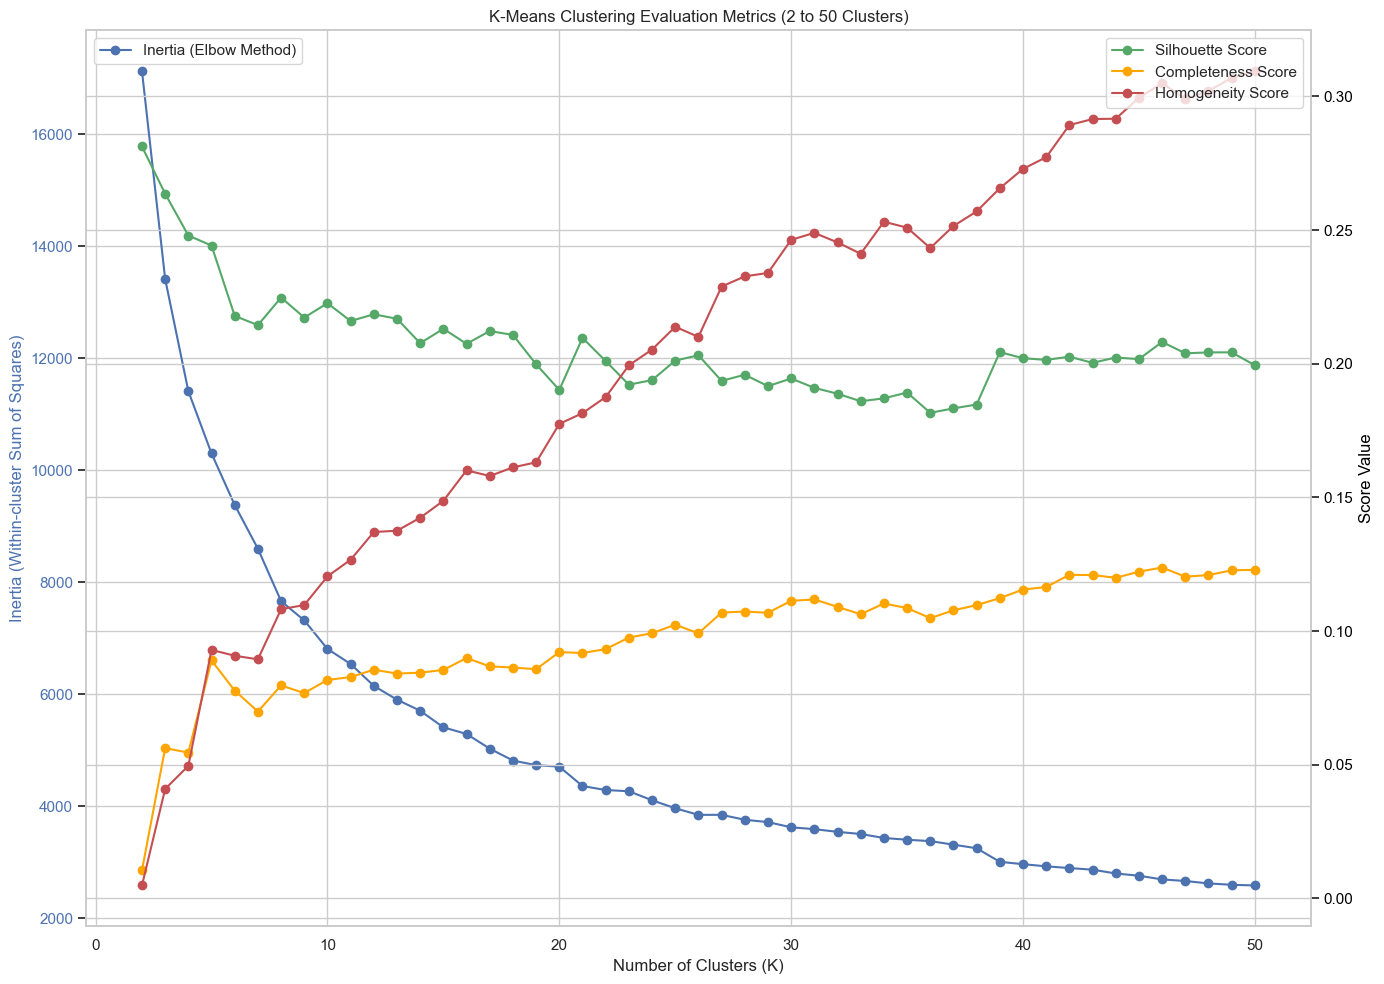

In [43]:
#Figure 9:

X = football[['Score', 'Fouls', 'Corners', 'Possession', 'SucShots', 'ShotsAccuracy']]

# Initializing lists to store results
silhouette_scores = []
completeness_scores = []
homogeneity_scores = []
inertia = []

# Looping through K values from 2 to 50
for k in range(2, 51):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    
    # Calculate the evaluation metrics for each k
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    completeness_scores.append(completeness_score(football['Score'], kmeans.labels_))
    homogeneity_scores.append(homogeneity_score(football['Score'], kmeans.labels_))
    inertia.append(kmeans.inertia_)  # WSS (within-cluster sum of squares)

# Creating the plot 
fig, ax1 = plt.subplots(figsize=(14, 10))

# using the Elbow Method (Inertia) on the first y-axis
ax1.plot(range(2, 51), inertia, marker='o', label='Inertia (Elbow Method)', color='b')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Adding a second y-axis for the other metrics
ax2 = ax1.twinx()
ax2.plot(range(2, 51), silhouette_scores, marker='o', label='Silhouette Score', color='g')
ax2.plot(range(2, 51), completeness_scores, marker='o', label='Completeness Score', color='orange')
ax2.plot(range(2, 51), homogeneity_scores, marker='o', label='Homogeneity Score', color='r')
ax2.set_ylabel('Score Value', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Adding titles and a legend
plt.title('K-Means Clustering Evaluation Metrics (2 to 50 Clusters)')
fig.tight_layout()

# Combining legends 
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True)
plt.show()


In [45]:

X = football[['Fouls', 'Corners', 'Possession', 'SucShots', 'ShotsAccuracy']] # Cambia si es necesario
 
y = football['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [49]:
X = football[['Fouls', 'Corners', 'Possession', 'SucShots', 'ShotsAccuracy']]  # Adjust as needed
y = football['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---- Modelo 1: Regresión Logística ----
print("Entrenando Regresión Logística...")
log_model = LogisticRegression(max_iter=1000)  # Crear el modelo
log_model.fit(X_train, y_train)  # Entrenar el modelo

# Hacer predicciones
log_preds = log_model.predict(X_test)

# Evaluar el modelo
print("\nResultados de Regresión Logística:")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, log_preds))
print("\nReporte de Clasificación:")
print(classification_report(y_test, log_preds))


Entrenando Regresión Logística...

Resultados de Regresión Logística:
Matriz de Confusión:
[[32 36  9  1  0  0  0  0  0]
 [15 36 12  2  0  0  0  0  0]
 [ 1 23 23  3  0  0  0  0  0]
 [ 0  9  8  6  0  0  0  0  0]
 [ 0  2  4  1  0  0  0  0  0]
 [ 0  1  1  1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  1  0  0]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.67      0.41      0.51        78
           1       0.34      0.55      0.42        65
           2       0.40      0.46      0.43        50
           3       0.43      0.26      0.32        23
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1

    accuracy                           0.43       228
   macro avg   

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels wi

In [53]:
# ---- Modelo 2: Árbol de Decisión ----
print("Entrenando Árbol de Decisión...")
tree_model = DecisionTreeClassifier()  # Crear el modelo
tree_model.fit(X_train, y_train)  # Entrenar el modelo

# Hacer predicciones
tree_preds = tree_model.predict(X_test)

# Evaluar el modelo
print("\nResultados de Árbol de Decisión:")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, tree_preds))
print("\nReporte de Clasificación:")
print(classification_report(y_test, tree_preds))


Entrenando Árbol de Decisión...

Resultados de Árbol de Decisión:
Matriz de Confusión:
[[34 33 10  1  0  0  0  0]
 [17 26 15  5  2  0  0  0]
 [ 8 11 21  9  1  0  0  0]
 [ 3  6  8  2  3  1  0  0]
 [ 2  2  2  1  0  0  0  0]
 [ 0  1  0  1  1  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  1  0  0  0  0  0]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.53      0.44      0.48        78
           1       0.33      0.40      0.36        65
           2       0.37      0.42      0.39        50
           3       0.10      0.09      0.09        23
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1

    accuracy                           0.36       228
   macro avg       0.17      0.17      0.17       228
weighted avg       0.37      0.36      0.36       228



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
#SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)



X_test_scaled = scaler.transform(X_test)


In [67]:
#RESULTS

scaler = StandardScaler()
 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)
print("First rows of scaled X_train:") 
print(X_train_scaled[:5])




First rows of scaled X_train:
[[ 0.36544416  0.21007727  0.22618047 -0.87161738 -0.84634451]
 [-1.80815416  0.21007727  2.20136315  0.84738334 -0.11531178]
 [ 0.84846601  1.17910419  0.54220987 -0.4418672  -0.05439225]
 [-0.84211046 -0.75894966  0.77923204  1.7068837   0.25020464]
 [ 1.33148786  0.21007727  0.30518818 -1.30136755 -0.54174753]]


In [71]:
#TRAINING

log_model = LogisticRegression(max_iter=1000) 
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

print("Predictions:", log_preds[:10])




Predictions: [0 1 1 0 2 1 1 0 2 0]


In [73]:

log_model = LogisticRegression(max_iter=1000, random_state=42) 
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)


print("Confusion Matrix:") 
print(confusion_matrix(y_test, log_preds)) 
print("\nClassification Report:") 
print(classification_report(y_test, log_preds))


Confusion Matrix:
[[32 37  8  1  0  0  0  0]
 [17 34 12  2  0  0  0  0]
 [ 1 25 20  4  0  0  0  0]
 [ 0  9  8  5  1  0  0  0]
 [ 0  2  4  1  0  0  0  0]
 [ 0  1  1  1  0  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  1  0  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.41      0.50        78
           1       0.31      0.52      0.39        65
           2       0.38      0.40      0.39        50
           3       0.36      0.22      0.27        23
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1

    accuracy                           0.40       228
   macro avg       0.21      0.19      0.19       228
weighted avg       0.43      0.40      0.40       228



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


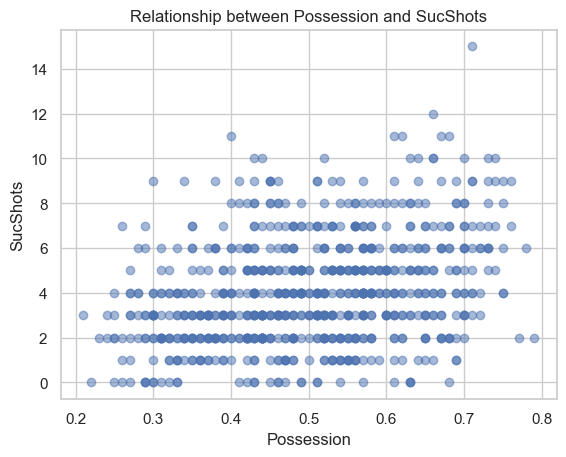

In [77]:

# Possession vs. Scatter Chart SucShots 
plt.scatter(football['Possession'], football['SucShots'], alpha=0.5) 
plt.title("Relationship between Possession and SucShots") 
plt.xlabel("Possession")
plt.ylabel("SucShots") 
plt.show()



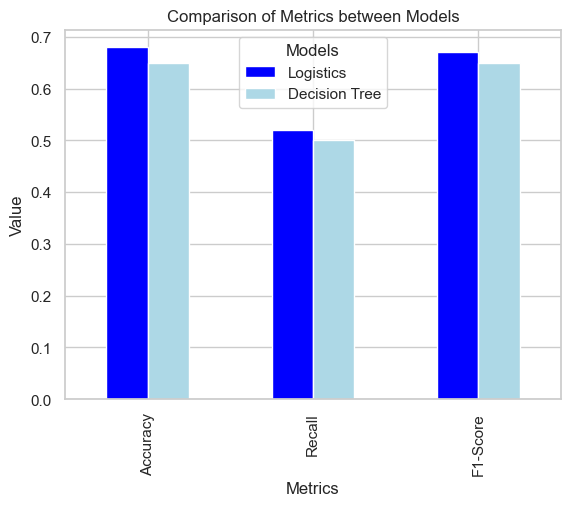

In [85]:
#Figure 10

# Model metrics
metrics = {
    "Logistics": [0.68, 0.52, 0.67],  # Replace with your metrics
    "Decision Tree": [0.65, 0.50, 0.65]
}

# Create DataFrame with metrics
df_metrics = pd.DataFrame(metrics, index=["Accuracy", "Recall", "F1-Score"])

# Bar chart with blue colors
df_metrics.plot(kind='bar', color=['blue', 'lightblue'])
plt.title("Comparison of Metrics between Models")
plt.ylabel("Value")
plt.xlabel("Metrics")
plt.legend(title="Models")
plt.show()


In [91]:
# RELATIONSHIP WITH THE ANALYSIS NO SUPERVISED

# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Replace X with your selected features

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust the number of clusters based on your analysis
kmeans.fit(X_scaled)


KMeans(n_clusters=3, random_state=42)

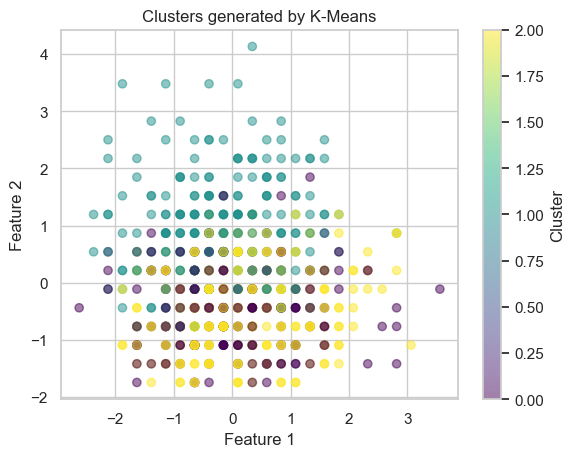

Confusion Matrix:
[[32 32 14]
 [15 23 27]
 [ 1 21 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.41      0.51        78
           1       0.30      0.35      0.33        65
           2       0.61      0.74      0.67        85

    accuracy                           0.52       228
   macro avg       0.53      0.50      0.50       228
weighted avg       0.54      0.52      0.52       228

         Feature  Coefficient
0          Fouls    -0.023910
1        Corners     0.033781
2     Possession     0.458647
3       SucShots    -0.466028
4  ShotsAccuracy    -0.929221
5  Cluster_Label     0.000000
Available teams:
['Liverpool' 'Norwich City' 'West Ham United' 'Manchester City' 'Burnley'
 'Southampton' 'Watford' 'Brighton & Hove Albion' 'Bournemouth'
 'Sheffield United' 'Crystal Palace' 'Everton' 'Tottenham Hotspur'
 'Aston Villa' 'Newcastle United' 'Arsenal' 'Leicester City'
 'Wolverhampton Wanderers' 'Manchester United' 

In [99]:
#Figure 11 

# Cluster chart
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.title("Clusters generated by K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster')
plt.show()

### Code Cell
football['Result'] = football['Score'].apply(lambda x: 0 if x == 0 else (1 if x == 1 else 2))
if 'Cluster_Label' not in football.columns:
    football['Cluster_Label'] = 0

### Code Cell
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select features and target variable
X = football[['Fouls', 'Corners', 'Possession', 'SucShots', 'ShotsAccuracy', 'Cluster_Label']]
y = football['Result']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

### Code Cell
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = log_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Code Cell
# Model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})
print(coefficients)

### Code Cell
print("Available teams:")
print(football['Team'].unique())

print("\nAvailable match dates:")
print(football['Match_Date'].unique())
